The top 20 States in the United States ordered by number of fatalities.

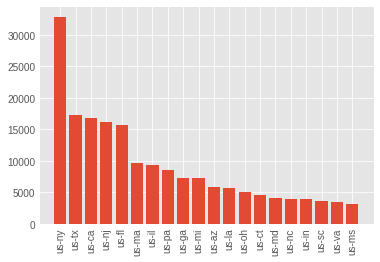

In [51]:
import requests
from pprint import pprint
from datetime import datetime
import matplotlib.pyplot as plt
plt.style.use('ggplot')

def to_date(s):
    """Convert DD-MM-YYYY format to a datetime object"""
    dd, mm, yyyy = s.split('-')
    return datetime(int(yyyy), int(mm), int(dd))

data = requests.get('http://langlynx.ddns.net:8000/latest_case_data',
                    params={'schema': 'admin_1',
                            'region_parent': 'us',
                            'datatype': 'status_deaths'}).json()['nytimes']['status_deaths']

labels = []
totals = []

for state_iso, state_item in sorted(data.items(),
                                    key=lambda i: i[1]['value'],
                                    reverse=True)[:20]:
    labels.append(state_iso)
    totals.append(state_item['value'])

plt.bar(labels, totals)
plt.xticks(rotation='vertical')
plt.show()

Below is an example of how to make some basic plots comparing the
totals of a few countries over time.

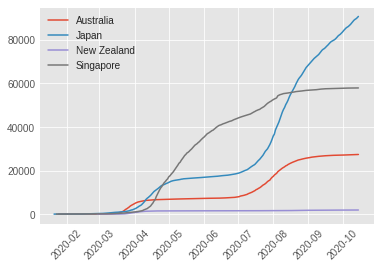

In [52]:
import requests
from datetime import datetime
import matplotlib.pyplot as plt
plt.style.use('ggplot')

def to_date(s):
    """Convert DD-MM-YYYY format to a datetime object"""
    dd, mm, yyyy = s.split('-')
    return datetime(int(yyyy), int(mm), int(dd))

for country_iso, country_name in (('au', 'Australia'), ('jp', 'Japan'),
                                  ('nz', 'New Zealand'), ('sg', 'Singapore')):
    params = {'schema': 'admin_0',
              'region_parent': '',
              'region_child': country_iso,
              'datatype': 'total'}

    data = requests.get('http://langlynx.ddns.net:8000/case_data_time_series',
                        params=params).json()

    dates = [to_date(i[0]) for i in data['bing']['total']]
    totals = [i[1] for i in data['bing']['total']]
    plt.plot(dates, totals, label=country_name)
    plt.legend()

plt.xticks(rotation='45')
plt.show()

Some sources, such as many Australia states also support age breakdowns.

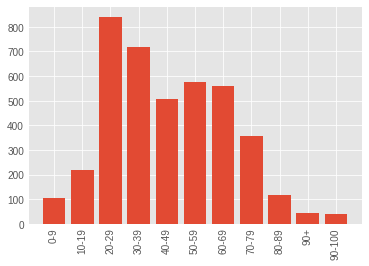

In [53]:
import requests
from datetime import datetime
import matplotlib.pyplot as plt
plt.style.use('ggplot')

def to_date(s):
    """Convert DD-MM-YYYY format to a datetime object"""
    dd, mm, yyyy = s.split('-')
    return datetime(int(yyyy), int(mm), int(dd))

data = requests.get('http://langlynx.ddns.net:8000/latest_case_data',
                    params={'schema': 'admin_1',
                            'region_parent': 'au',
                            'region_child': 'au-nsw',
                            'datatype': 'total',
                            'age_breakdowns': True}).json()['nsw']['total']

labels = []
totals = []

for age, age_item in sorted(data.items(),
                            # Sort 0-9 before others
                            key=lambda i: '00-09' if i[0] == '0-9' else i[0]
                            )[:20]:
    labels.append(age)
    totals.append(age_item['value'])

plt.bar(labels, totals)
plt.xticks(rotation='vertical')
plt.show()

Such sources also usually support basic gender breakdowns.


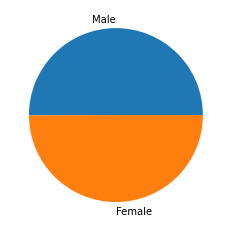

In [13]:
import requests
from datetime import datetime
import matplotlib.pyplot as plt

def to_date(s):
    """Convert DD-MM-YYYY format to a datetime object"""
    dd, mm, yyyy = s.split('-')
    return datetime(int(yyyy), int(mm), int(dd))

data = requests.get('http://langlynx.ddns.net:8000/latest_case_data',
                    params={'schema': 'admin_1',
                            'region_parent': 'au',
                            'region_child': 'au-nsw'}
                    ).json()['nsw_website_data']

labels = ['Male', 'Female']
totals = [data['total_male']['value'], data['total_female']['value']]

plt.pie(totals, labels=labels)
plt.show()


It's also possible to show cases by source of infection when this is provided.

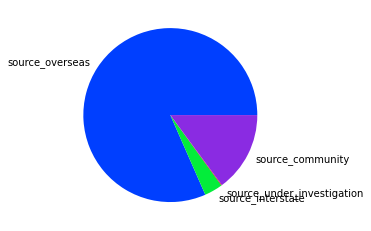

In [3]:
import requests
from datetime import datetime
import matplotlib.pyplot as plt

def to_date(s):
    """Convert DD-MM-YYYY format to a datetime object"""
    dd, mm, yyyy = s.split('-')
    return datetime(int(yyyy), int(mm), int(dd))

data = requests.get('http://langlynx.ddns.net:8000/latest_case_data',
                    params={'schema': 'admin_1',
                            'region_parent': 'au',
                            'region_child': 'au-nsw'}
                    ).json()['nsw']

labels = ['source_overseas', 'source_interstate',
          'source_under_investigation', 'source_community']
totals = [data['source_overseas']['value'],
          data['source_interstate']['value'],
          data['source_under_investigation']['value'],
          data['source_community']['value'],]

plt.pie(totals, labels=labels)
plt.show()

Anonymized user movement data is provided by Google for many regions.
This can be time-shifted and plotted against other data to get an idea
of the kinds of factors which may have influenced a rise in cases.

We will be averaging over 7 days to minimize the differences in activities
that are often seen e.g. during the week vs weekends, and timeshifting
movement data forwards 12 days to get a feel for whether there's a
correlation between different predictors and changes in case numbers.

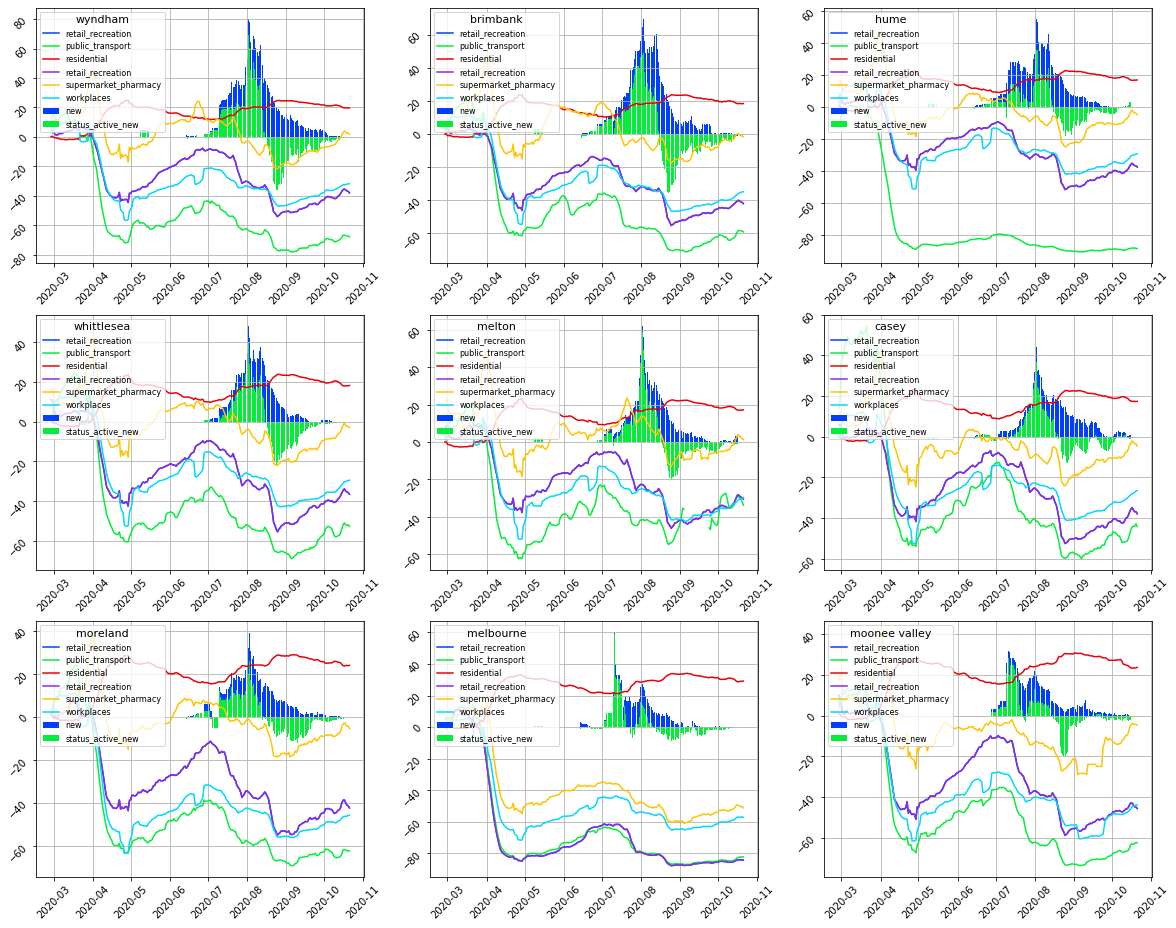

In [7]:
import requests
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use('seaborn-bright')

def to_date(s):
    """Convert DD-MM-YYYY format to a datetime object"""
    dd, mm, yyyy = s.split('-')
    return datetime(int(yyyy), int(mm), int(dd))

# Show the Google mobility data
data = requests.get('http://langlynx.ddns.net:8000/case_data_time_series',
                    params={'schema': 'lga',
                            'region_parent': 'au-vic'}
                    ).json()
google_mobility = data['google_mobility']
vic_dhhs = data['vic_press_releases']

region_children = [(vic_dhhs['total'][k][-1][1], k) for k in vic_dhhs['total']]
region_children = [i[1] for i in sorted(region_children, reverse=True)][:9]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 16))

for subplot_idx, region_child in enumerate(region_children):
    subplot = axes[subplot_idx // 3, subplot_idx % 3]

    labels = [
        'google_mobility_retail_recreation', 'google_mobility_public_transport',
        'google_mobility_residential', 'google_mobility_retail_recreation',
        'google_mobility_supermarket_pharmacy', 'google_mobility_workplaces',
    ]
    totals = []

    for label in labels:
        dates = [to_date(i[0])+timedelta(days=12) for i in google_mobility[label][region_child]]
        totals = [i[1] for i in data['google_mobility'][label][region_child]]

        df = pd.DataFrame(data={'dates': pd.to_datetime(dates),
                                'totals': totals}
                          ).set_index('dates')
        df = df.apply(lambda x: x.resample('1D').first())
        df = df.apply(lambda x: x.shift().rolling(min_periods=1, window=7).mean())

        subplot.plot(df.index, df['totals'],
                     label=label.replace('google_mobility_', ''))

    # Show the new/active/deaths numbers
    labels = ['new', 'status_active_new']

    for label in labels:
        totals = [i[1] for i in vic_dhhs[label][region_child] if i[1] > -100]
        dates = [to_date(i[0]) for i in vic_dhhs[label][region_child] if i[1] > -100]

        df = pd.DataFrame(data={'dates': pd.to_datetime(dates),
                                'totals': totals}
                          ).set_index('dates')
        df = df.apply(lambda x: x.resample('1D').first())
        df = df.apply(lambda x: x.shift().rolling(min_periods=1, window=7).mean())

        subplot.bar(df.index, df['totals'], label=label)

    leg = subplot.legend(loc='upper left', fontsize=8)
    leg.set_title(region_child, prop={'size': 11})
    subplot.tick_params(labelrotation=45)
    subplot.grid()

plt.show()